*In scikit-learn (and statistics in general), variance measures how spread out your data is.*

Intuition
Low variance → data points are close to the mean
High variance → data points are widely spread out

Think of it as:

“How much do the values differ from the average?”


You square the differences so negative and positive deviations don’t cancel out.

Why variance matters in scikit-learn
1. In scaling

With StandardScaler:

It makes variance = 1
So all features are on the same scale
2. In PCA (dimensionality reduction)

With PCA:

It finds directions with maximum variance
Why? Because:
High variance = more information
Low variance = less useful / noise
3. Feature selection

Sometimes features with very low variance are removed because:

they barely change
they don’t help models learn

Variance and standard deviation are closely related—they measure the same idea (spread of data), but in slightly different ways.

The relationship
Variance = average of squared deviations from the mean
Standard deviation = square root of variance
Standard Deviation=
Variance
	​

Key difference (intuition)

🔹 Variance
Units are squared
If data is in meters → variance is in m²
Harder to interpret directly
Used more in mathematical operations (like in PCA)

🔹 Standard Deviation
Units are the same as the data
If data is in meters → std is in meters
Easier to understand
Used more for interpretation and reporting

In [54]:
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [55]:
X, Y = load_breast_cancer(return_X_y=True)


In [56]:
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [57]:
df = load_breast_cancer(as_frame=True).frame #this is a pandas dataframe

In [58]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [59]:
df2 = fetch_california_housing(as_frame=True).frame #fetching is different from loading, fetching means downloading the data from the internet
df2

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


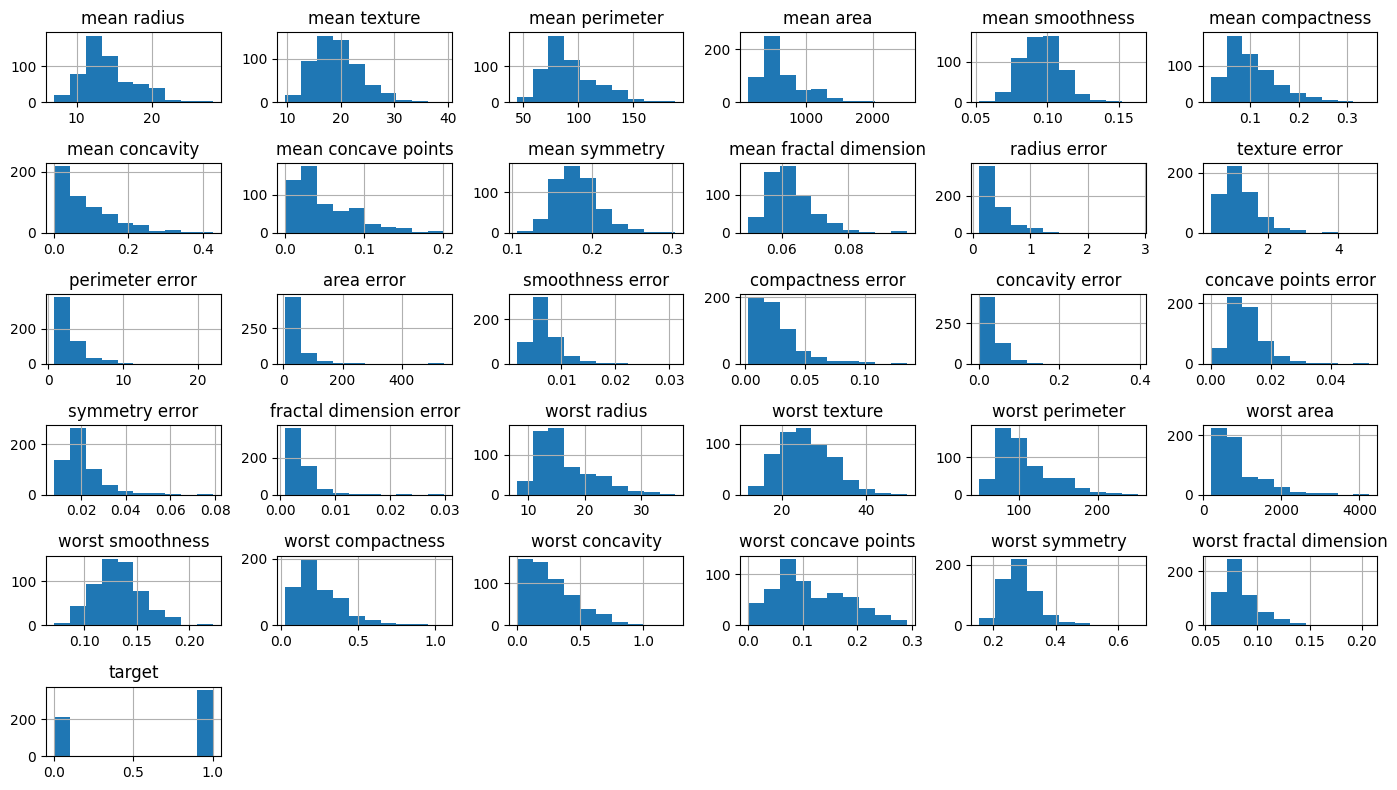

In [60]:
import matplotlib.pyplot as plt

df.hist(figsize = (14, 8))
plt.tight_layout()

In [61]:
from sklearn.datasets import make_blobs, make_moons #creates cluster of data points

In [62]:
X, y = make_blobs(n_samples=500, centers=5)

In [63]:
X

array([[-5.345679  ,  9.55462406],
       [-3.66080638,  0.82462378],
       [ 7.13797194,  5.11469838],
       [-9.13564766,  2.61906064],
       [-5.79960373,  9.93993779],
       [ 5.34718761,  5.28544385],
       [-7.03538264, 10.01727534],
       [-6.09373714,  9.19570032],
       [ 7.29015733,  5.70043611],
       [ 5.78105596,  6.71409841],
       [-6.78611151, -0.58694949],
       [-1.26813942,  0.7692642 ],
       [-3.77601644,  0.09717259],
       [-6.50863194,  8.88778268],
       [-3.2658469 ,  9.91430146],
       [ 3.32481197,  6.43525181],
       [-7.30488979,  0.25208687],
       [ 8.37761605,  2.35876788],
       [ 6.44848197,  4.71418883],
       [-5.32620606,  2.07246527],
       [ 9.15108963,  3.43105232],
       [-5.71802768,  8.92057533],
       [-6.64765592, -0.44997202],
       [-5.73382437,  9.76741276],
       [-3.02092902,  8.23635092],
       [ 4.91730186,  8.48539632],
       [ 5.69704626,  4.82827629],
       [ 4.72405193,  6.887334  ],
       [ 4.50075487,

In [64]:
y

array([2, 0, 4, 0, 2, 4, 2, 2, 4, 1, 0, 3, 3, 2, 2, 1, 0, 4, 4, 0, 4, 2,
       0, 2, 2, 1, 4, 1, 1, 3, 1, 0, 3, 1, 4, 0, 0, 3, 4, 3, 2, 0, 2, 1,
       0, 1, 4, 2, 3, 4, 3, 3, 3, 3, 2, 2, 4, 2, 2, 1, 1, 0, 3, 4, 3, 4,
       2, 3, 0, 1, 4, 4, 3, 2, 3, 4, 1, 3, 3, 2, 0, 4, 0, 2, 3, 4, 3, 1,
       0, 3, 1, 2, 3, 2, 4, 4, 2, 2, 4, 2, 1, 2, 0, 3, 2, 3, 1, 1, 4, 4,
       3, 1, 0, 4, 3, 3, 0, 2, 0, 3, 1, 3, 3, 4, 3, 1, 1, 2, 0, 1, 1, 1,
       4, 0, 2, 4, 4, 1, 0, 0, 4, 2, 1, 1, 2, 1, 1, 1, 3, 4, 3, 2, 1, 4,
       1, 0, 1, 3, 0, 0, 0, 1, 4, 2, 1, 1, 2, 1, 1, 3, 0, 2, 1, 3, 3, 3,
       4, 1, 0, 1, 3, 4, 0, 1, 1, 0, 4, 3, 4, 3, 0, 2, 3, 0, 4, 1, 4, 2,
       3, 3, 2, 2, 0, 1, 1, 1, 2, 3, 0, 0, 0, 1, 4, 0, 3, 4, 0, 0, 4, 3,
       1, 2, 0, 3, 1, 0, 0, 2, 4, 0, 1, 3, 2, 4, 1, 4, 4, 2, 4, 2, 3, 4,
       3, 0, 4, 2, 0, 0, 1, 1, 1, 2, 4, 4, 2, 0, 0, 3, 1, 0, 3, 0, 4, 0,
       4, 3, 2, 3, 2, 2, 1, 2, 3, 3, 3, 0, 2, 3, 0, 3, 4, 4, 0, 2, 2, 0,
       3, 3, 1, 0, 0, 1, 1, 4, 2, 2, 2, 3, 1, 4, 4,

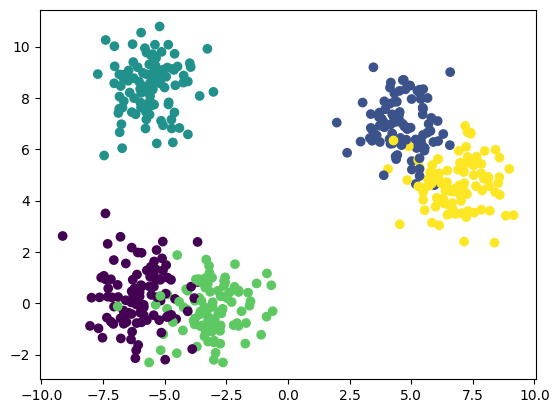

In [65]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [66]:
from sklearn.datasets import make_moons #different clustering method

In [67]:
X, y = make_moons(n_samples=500, noise=0.1) #if the random state is not set, the plot will lookf different everytime

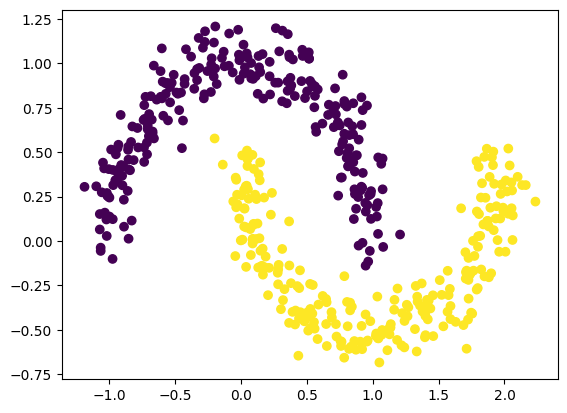

In [68]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [69]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [70]:
data = load_iris()

X, y = data.data, data.target

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) # 20% testing, 80% training
#from train_test_split we get 4 variables, X_train, X_test, y_train, y_test. 

In [72]:
len(X_train)

120

In [73]:
len(X_test)

30

([<matplotlib.axis.XTick at 0x1f5f2c25810>,
 [Text(0, 0, 'setosa'), Text(1, 0, 'versicolor'), Text(2, 0, 'virginica')])

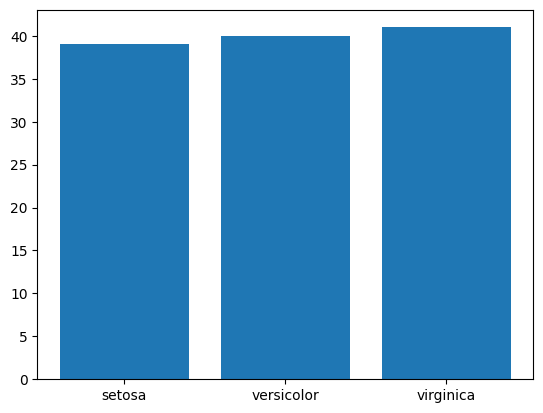

In [74]:
import numpy as np
import matplotlib.pyplot as plt

counts = np.bincount(y_train)
positions = np.arange(len(counts))

plt.bar(positions, counts)
plt.xticks(positions, data.target_names)

#here we can see that the splitting of the data is not even, we have more samples of class 0 than class 1 and class 2. This is called imbalanced data, and it can be a problem for some machine learning algorithms. We will see how to deal with imbalanced data in a later section.

([<matplotlib.axis.XTick at 0x1f5f2c8a5d0>,
 [Text(0, 0, 'setosa'), Text(1, 0, 'versicolor'), Text(2, 0, 'virginica')])

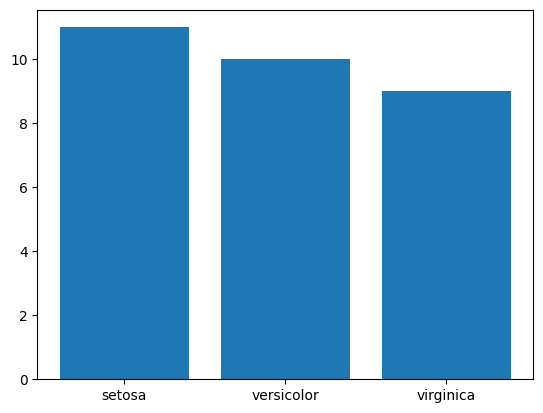

In [75]:
import numpy as np
import matplotlib.pyplot as plt

counts = np.bincount(y_test)
positions = np.arange(len(counts))

plt.bar(positions, counts)
plt.xticks(positions, data.target_names)

#here it is the opossite of the training data, we have more samples of class 1 than class 0 and class 2. 

##Sci-kit learn pre-processing Methods

In [76]:
from sklearn.model_selection import StratifiedShuffleSplit #Stratified means that the splitting of the data will be done in a way that preserves the proportion of the classes in the training and testing sets. 
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2)

for train_index, test_index in split.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    #sp if run the code above again, the splitting is even in each classes


In [77]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [78]:
X, y = load_iris(return_X_y=True)
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) 

In [80]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) 
#fit and tranforming : we learn the values from the training data. We apply the scaling onto the training data. 
X_test_scaled = scaler.transform(X_test)

In [81]:
X_train_scaled #this is the scaled version of the training data, we can see that the values are now centered around 0 and have a standard deviation of 1.

array([[-1.76587477, -0.39545367, -1.32559302, -1.29534603],
       [-0.02793124, -0.83895311,  0.77566832,  0.93085945],
       [-1.02104183,  0.71329493, -1.26880217, -1.29534603],
       [-1.26931948,  0.04804577, -1.21201132, -1.29534603],
       [ 1.58587348, -0.17370395,  1.22999509,  1.19276597],
       [ 0.09620759, -0.17370395,  0.77566832,  0.79990618],
       [ 0.71690171,  0.04804577,  1.0028317 ,  0.79990618],
       [-0.02793124, -0.83895311,  0.20775985, -0.24771992],
       [-0.52448653,  0.71329493, -1.26880217, -1.0334395 ],
       [-1.51759712,  0.26979549, -1.32559302, -1.29534603],
       [ 0.71690171,  0.26979549,  0.43492324,  0.40704639],
       [ 0.46862406,  0.71329493,  0.94604086,  1.4546725 ],
       [-1.26931948,  0.71329493, -1.21201132, -1.29534603],
       [-0.02793124, -0.83895311,  0.77566832,  0.93085945],
       [-0.15207006,  1.60029382, -1.15522048, -1.16439276],
       [-0.40034771, -1.28245255,  0.150969  ,  0.14513987],
       [-1.14518065, -1.

In [82]:
import numpy as np

(X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0) #this is how we can do the scaling manually, but it is better to use the StandardScaler from sklearn because it is more efficient and it also has some additional features.

array([[-1.76587477, -0.39545367, -1.32559302, -1.29534603],
       [-0.02793124, -0.83895311,  0.77566832,  0.93085945],
       [-1.02104183,  0.71329493, -1.26880217, -1.29534603],
       [-1.26931948,  0.04804577, -1.21201132, -1.29534603],
       [ 1.58587348, -0.17370395,  1.22999509,  1.19276597],
       [ 0.09620759, -0.17370395,  0.77566832,  0.79990618],
       [ 0.71690171,  0.04804577,  1.0028317 ,  0.79990618],
       [-0.02793124, -0.83895311,  0.20775985, -0.24771992],
       [-0.52448653,  0.71329493, -1.26880217, -1.0334395 ],
       [-1.51759712,  0.26979549, -1.32559302, -1.29534603],
       [ 0.71690171,  0.26979549,  0.43492324,  0.40704639],
       [ 0.46862406,  0.71329493,  0.94604086,  1.4546725 ],
       [-1.26931948,  0.71329493, -1.21201132, -1.29534603],
       [-0.02793124, -0.83895311,  0.77566832,  0.93085945],
       [-0.15207006,  1.60029382, -1.15522048, -1.16439276],
       [-0.40034771, -1.28245255,  0.150969  ,  0.14513987],
       [-1.14518065, -1.

In [83]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train) 
#fit and tranforming : we learn the values from the training data. We apply the scaling onto the training data. 
X_test_scaled = scaler.transform(X_test)


In [84]:
X_train_scaled

array([[0.02777778, 0.375     , 0.07017544, 0.04166667],
       [0.41666667, 0.29166667, 0.71929825, 0.75      ],
       [0.19444444, 0.58333333, 0.0877193 , 0.04166667],
       [0.13888889, 0.45833333, 0.10526316, 0.04166667],
       [0.77777778, 0.41666667, 0.85964912, 0.83333333],
       [0.44444444, 0.41666667, 0.71929825, 0.70833333],
       [0.58333333, 0.45833333, 0.78947368, 0.70833333],
       [0.41666667, 0.29166667, 0.54385965, 0.375     ],
       [0.30555556, 0.58333333, 0.0877193 , 0.125     ],
       [0.08333333, 0.5       , 0.07017544, 0.04166667],
       [0.58333333, 0.5       , 0.61403509, 0.58333333],
       [0.52777778, 0.58333333, 0.77192982, 0.91666667],
       [0.13888889, 0.58333333, 0.10526316, 0.04166667],
       [0.41666667, 0.29166667, 0.71929825, 0.75      ],
       [0.38888889, 0.75      , 0.12280702, 0.08333333],
       [0.33333333, 0.20833333, 0.52631579, 0.5       ],
       [0.16666667, 0.20833333, 0.61403509, 0.66666667],
       [0.61111111, 0.41666667,

In [85]:
X_min = np.min(X_train, axis = 0)
X_max = np.max(X_train, axis = 0)

(X_train - X_min) / (X_max - X_min) #this is how we can do the scaling manually, but it is better to use the MinMaxScaler from sklearn because it is more efficient and it also has some additional features.

array([[0.02777778, 0.375     , 0.07017544, 0.04166667],
       [0.41666667, 0.29166667, 0.71929825, 0.75      ],
       [0.19444444, 0.58333333, 0.0877193 , 0.04166667],
       [0.13888889, 0.45833333, 0.10526316, 0.04166667],
       [0.77777778, 0.41666667, 0.85964912, 0.83333333],
       [0.44444444, 0.41666667, 0.71929825, 0.70833333],
       [0.58333333, 0.45833333, 0.78947368, 0.70833333],
       [0.41666667, 0.29166667, 0.54385965, 0.375     ],
       [0.30555556, 0.58333333, 0.0877193 , 0.125     ],
       [0.08333333, 0.5       , 0.07017544, 0.04166667],
       [0.58333333, 0.5       , 0.61403509, 0.58333333],
       [0.52777778, 0.58333333, 0.77192982, 0.91666667],
       [0.13888889, 0.58333333, 0.10526316, 0.04166667],
       [0.41666667, 0.29166667, 0.71929825, 0.75      ],
       [0.38888889, 0.75      , 0.12280702, 0.08333333],
       [0.33333333, 0.20833333, 0.52631579, 0.5       ],
       [0.16666667, 0.20833333, 0.61403509, 0.66666667],
       [0.61111111, 0.41666667,

### Feature Encoder

In [86]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OrdinalEncoder

In [87]:
data = fetch_openml("car", as_frame=True).frame

C:\Users\yamin\AppData\Roaming\Python\Python313\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name car exist. Versions may be fundamentally different, returning version 2. Available versions:
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=991
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=40975

  warn(warning_msg)


In [88]:
data
#note: the numeric data can only be used for machine learning algorithms, but the categorical data needs to be encoded into numeric data before it can be used for machine learning algorithms.

,buying,maint,doors,persons,lug_boot,safety,binaryClass
0,vhigh,vhigh,2,2,small,low,P
1,vhigh,vhigh,2,2,small,med,P
2,vhigh,vhigh,2,2,small,high,P
3,vhigh,vhigh,2,2,med,low,P
4,vhigh,vhigh,2,2,med,med,P
...,...,...,...,...,...,...,...
1723,low,low,5more,more,med,med,N
1724,low,low,5more,more,med,high,N
1725,low,low,5more,more,big,low,P
1726,low,low,5more,more,big,med,N


In [89]:
columns_to_encode = ['lug_boot', 'safety'] #these are the columns that we want to encode, we will use the OrdinalEncoder from sklearn to encode these columns.

encoder = OrdinalEncoder(
    categories =[
        ['small', 'med', 'big'],
        ['low', 'med', 'high'],
        ]
)
data[columns_to_encode] = encoder.fit_transform(data[columns_to_encode])

In [90]:
data

,buying,maint,doors,persons,lug_boot,safety,binaryClass
0,vhigh,vhigh,2,2,0.0,0.0,P
1,vhigh,vhigh,2,2,0.0,1.0,P
2,vhigh,vhigh,2,2,0.0,2.0,P
3,vhigh,vhigh,2,2,1.0,0.0,P
4,vhigh,vhigh,2,2,1.0,1.0,P
...,...,...,...,...,...,...,...
1723,low,low,5more,more,1.0,1.0,N
1724,low,low,5more,more,1.0,2.0,N
1725,low,low,5more,more,2.0,0.0,P
1726,low,low,5more,more,2.0,1.0,N


In [91]:
encoder.inverse_transform(data[columns_to_encode]) # this is how we can decode the encoded data back to the original categorical data, but it is better to use the OrdinalEncoder from sklearn because it is more efficient and it also has some additional features.

array([['small', 'low'],
       ['small', 'med'],
       ['small', 'high'],
       ...,
       ['big', 'low'],
       ['big', 'med'],
       ['big', 'high']], shape=(1728, 2), dtype=object)

#### One-Hot Encoder

- there is no progression in the data (no high or low)
- decision tree (yes or no)

In [92]:
data = fetch_openml('adult', as_frame= True).frame

C:\Users\yamin\AppData\Roaming\Python\Python313\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name adult exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=179
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=1590

  warn(warning_msg)


In [93]:
data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capitalgain,capitalloss,hoursperweek,native-country,class
0,2,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,1,0,2,United-States,<=50K
1,3,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,0,United-States,<=50K
2,2,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,2,United-States,<=50K
3,3,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,2,United-States,<=50K
4,1,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,2,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,2,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,2,United-States,<=50K
48838,4,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,2,United-States,<=50K
48839,2,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,3,United-States,<=50K
48840,2,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,2,0,2,United-States,<=50K


In [94]:
from sklearn.preprocessing import OneHotEncoder

In [95]:
data.occupation.value_counts()

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

In [96]:
import pandas as pd

encoder = OneHotEncoder(handle_unknown = 'ignore', sparse_output =False)

encoded_values = encoder.fit_transform(data[['occupation', 'race']])

new_cols =  encoder.get_feature_names_out(['occupation', 'race'])

In [97]:
new_cols

array(['occupation_Adm-clerical', 'occupation_Armed-Forces',
       'occupation_Craft-repair', 'occupation_Exec-managerial',
       'occupation_Farming-fishing', 'occupation_Handlers-cleaners',
       'occupation_Machine-op-inspct', 'occupation_Other-service',
       'occupation_Priv-house-serv', 'occupation_Prof-specialty',
       'occupation_Protective-serv', 'occupation_Sales',
       'occupation_Tech-support', 'occupation_Transport-moving',
       'occupation_nan', 'race_Amer-Indian-Eskimo',
       'race_Asian-Pac-Islander', 'race_Black', 'race_Other',
       'race_White'], dtype=object)

In [98]:
#merge together the encoded values with the original data, we will drop the original columns that we encoded and then concatenate the new encoded columns to the original data.
df_encoded = pd.DataFrame(encoded_values, columns = new_cols, index = data.index)

data_final = pd.concat(
    [data.drop(columns = ['occupation', 'race']), df_encoded],
    axis = 1
)

In [99]:
data_final

,age,workclass,fnlwgt,education,education-num,marital-status,relationship,sex,capitalgain,capitalloss,...,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_nan,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,2,State-gov,77516,Bachelors,13,Never-married,Not-in-family,Male,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,3,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Husband,Male,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2,Private,215646,HS-grad,9,Divorced,Not-in-family,Male,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,Private,234721,11th,7,Married-civ-spouse,Husband,Male,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1,Private,338409,Bachelors,13,Married-civ-spouse,Wife,Female,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,2,Private,215419,Bachelors,13,Divorced,Not-in-family,Female,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
48838,4,NaN,321403,HS-grad,9,Widowed,Other-relative,Male,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
48839,2,Private,374983,Bachelors,13,Married-civ-spouse,Husband,Male,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
48840,2,Private,83891,Bachelors,13,Divorced,Own-child,Male,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


#### Classification 

A classifier is an algorithm that learns from data to answer questions like:

“Is this email spam or not spam?”
“Is this tumor benign or malignant?”
“What digit (0–9) is this image?”

👉 So instead of predicting numbers like 3.14, it predicts classes like:

0 / 1
"cat" / "dog"
"yes" / "no"

🔹 How it works (basic idea)

You give it:

- Features (X) → input data (e.g., age, salary)
- Labels (y) → correct categories (e.g., buy / not buy)

The classifier:

Learns patterns from the training data
Uses those patterns to predict labels for new data
🔹 Common classifiers in scikit-learn

Here are some widely used ones:

- LogisticRegression → simple, fast, good baseline
- KNeighborsClassifier → based on nearest data points
- DecisionTreeClassifier → rule-based splits
- RandomForestClassifier → multiple trees combined
- SVC → powerful for complex boundaries
- GaussianNB → probabilistic approach

In [100]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [101]:
df = load_breast_cancer(as_frame = True).frame
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [102]:
X, y = load_breast_cancer(return_X_y = True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform (X_test)

In [103]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

#clf = LogisticRegression()
#clf = RandomForestClassifier()

clf = KNeighborsClassifier

clf.fit(X_train_scaled, y_train)

AttributeError: 'numpy.ndarray' object has no attribute '_validate_params'

In [ ]:
clf.score(X_test_scaled, y_test)

0.9649122807017544

In [ ]:
# making predicitions

single_instance = X_test_scaled[1]

In [ ]:
single_instance

array([ 0.63208237,  0.91309555,  0.70077891,  0.53488536,  0.07776137,
        0.81291068,  1.12617715,  0.99568518,  1.29450916, -0.10857548,
        0.08510254, -0.34136926,  0.04403431,  0.11015574, -0.45070062,
        0.71802145,  0.8814399 ,  0.73402598,  1.43666444,  0.08802196,
        0.62699263,  0.85810275,  0.63754951,  0.48016877,  0.40172116,
        1.2980712 ,  2.03681508,  1.66323307,  3.11579466,  0.62199697])

In [ ]:
clf.predict([single_instance]) # this predicts whether the tumor is malignant or benign, 0 = malignant, 1 = benign

array([0])

In [ ]:
y_test[1]

np.int64(0)

In [ ]:
# A predict probability function
clf.predict_proba([single_instance])

array([[1., 0.]])

#### Regression

it is basically on a continuous spectrum unlike classifier e.g. what is the price of this house?

In [ ]:
X, y = fetch_california_housing(return_X_y = True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform (X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

reg = LinearRegression()

reg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
reg.score(X_test_scaled, y_test) # this is not the accuracy, this is R2 score ( how much variance is explained by the model)

0.6023298423735173

In [ ]:
single_instance = X_test_scaled[0]

single_instance

array([-0.03306436, -1.88439421,  0.06767509, -0.08202137,  1.35668116,
       -0.04344363,  2.33575317, -1.38267837])

#### Clustering

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
X, _ = make_blobs(n_samples = 5000, centers = 5, random_state = 10)

X

array([[  6.17306585, -10.25446247],
       [ -8.13981972,   4.45135687],
       [  2.71307241,   4.32686739],
       ...,
       [ -6.91896111,   4.29323728],
       [ -3.95595105,   4.23150467],
       [  0.91461712,  -7.45569288]], shape=(5000, 2))

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

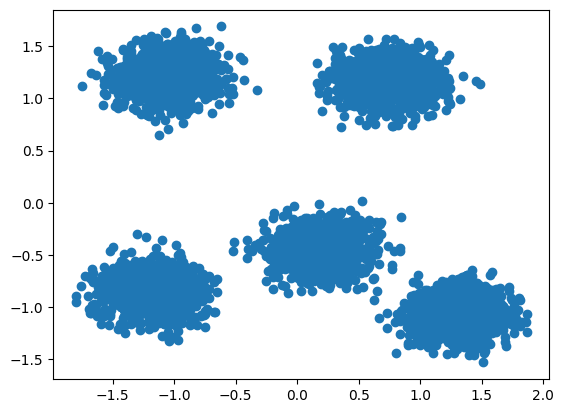

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_scaled[:, 0], X_scaled[:, 1]) # we get the unlabeled data blobs

##### how to find the cluster in n dimensional data?

In [ ]:
kmeans = KMeans(n_clusters=5)

kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


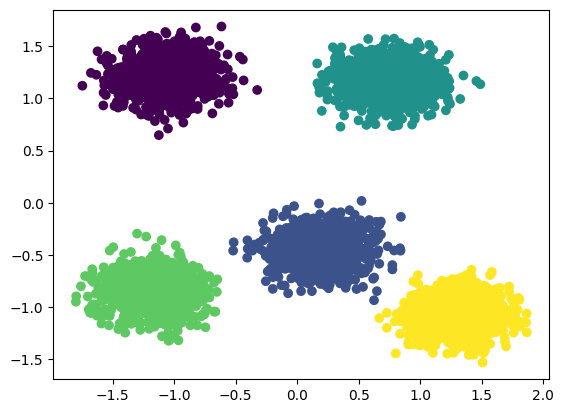

In [ ]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1],c=kmeans.labels_)

In [ ]:
from sklearn.datasets  import make_moons

X, _ = make_moons(n_samples = 5000, noise  = 0.08)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

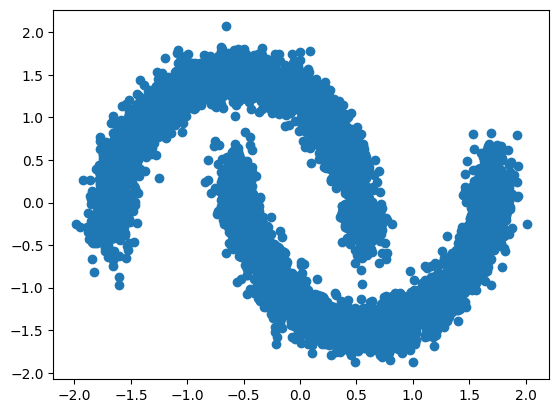

In [ ]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1])

In [ ]:
kmeans = KMeans(n_clusters=5)

kmeans.fit(X_scaled)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


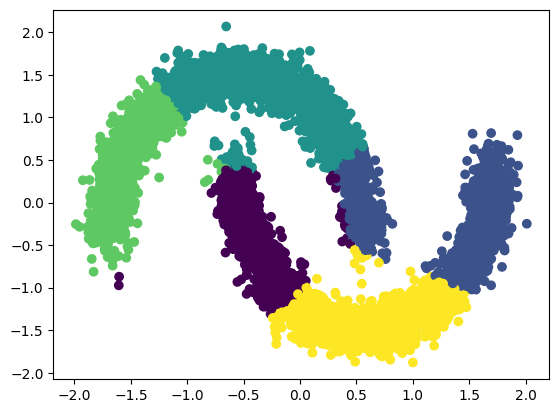

In [ ]:
plt.scatter(X_scaled[:, 0], X_scaled[:,1], c=kmeans.labels_)

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.2)
dbscan.fit(X_scaled)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.2
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


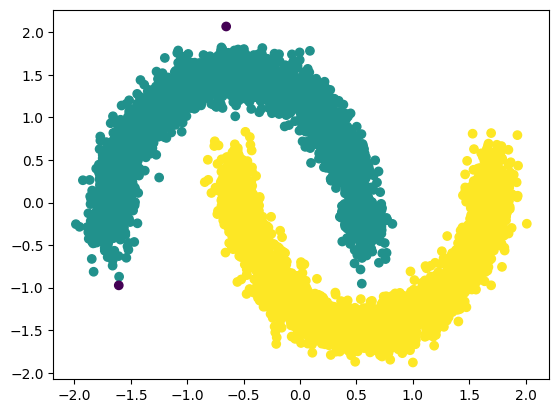

In [ ]:
plt.scatter(X_scaled[:, 0], X_scaled[:,1], c=dbscan.labels_)

#### Dimensionality Reduction (preprocessing)

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [ ]:
X, y = fetch_openml('mnist_784', return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:
pca = PCA(n_components = 10)

X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)

In [ ]:
X_train.shape

(56000, 784)

In [ ]:
X_train_reduced.shape

(56000, 10)

In [ ]:
clf = LogisticRegression(max_iter=100)
clf.fit(X_train, y_train)

print(clf.score(X_test, y_test))

0.9172142857142858


d:\dev\Learning-Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
clf = LogisticRegression(max_iter=100)
clf.fit(X_train_reduced, y_train)

print(clf.score(X_test_reduced, y_test))

0.8006428571428571


d:\dev\Learning-Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
pca.explained_variance_ratio_

array([0.09747258, 0.07171133, 0.06165926, 0.05418112, 0.04859922,
       0.04303424, 0.03290366, 0.02885822, 0.02752979, 0.02343808])

**1. PCA (Principal Component Analysis)**
PCA


Most common method


Finds new axes (directions) that capture maximum variance


Linear technique


Example:
from sklearn.decomposition import PCApca = PCA(n_components=2)X_reduced = pca.fit_transform(X)

**2. t-SNE**
t-SNE


Great for visualization (2D/3D)


Preserves local structure (clusters)


Slower, not ideal for large datasets



**3. UMAP (not in core sklearn but widely used)**
UMAP


Faster than t-SNE


Preserves both local and global structure



**4. Truncated SVD**
TruncatedSVD


Similar to PCA but works well with sparse data (e.g., text)

In [ ]:
X, y = load_breast_cancer(return_X_y= True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [ ]:
clf = KNeighborsClassifier()
clf.fit(X_train_scaled, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
clf.score(X_test_scaled, y_test) #Accuracy

0.9385964912280702

#### Metrics 

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred =clf.predict(X_test_scaled)

In scikit-learn, metrics are functions used to evaluate how well your model is performing.

Think of metrics as:

“How do we measure if our model is good or bad?”

Why metrics matter

After training a model, you need a quantitative way to judge it:

Is it accurate?
Is it making big errors?
Is it missing important cases?

Metrics give you those answers.

Types of metrics in scikit-learn

🔹 1. Classification metrics (for labels like 0/1, cat/dog)

Used when predicting categories.

Common ones:

- Accuracy: % of correct predictions
- Precision: Out of predicted positives, how many were correct
- Recall: Out of actual positives, how many were found
- F1-score: Balance between precision and recall

Example:

`from sklearn.metrics import accuracy_score`

`accuracy_score(y_true, y_pred)`

🔹 2. Regression metrics (for continuous values)

Used when predicting numbers.

Common ones:

Mean Squared Error (MSE)
penalizes large errors heavily
Mean Absolute Error (MAE)
average absolute difference
R² score
how well model explains variance

Example:

`from sklearn.metrics import mean_squared_error`

`mean_squared_error(y_true, y_pred)`

🔹 3. Clustering metrics (no labels or unsupervised learning)

Used for models like KMeans.

Examples:

Silhouette score
Adjusted Rand Index
Example

`from sklearn.metrics import accuracy_score`

`y_true = [1, 0, 1, 1]`

`y_pred = [1, 0, 0, 1]`

`accuracy_score(y_true, y_pred)`  # 0.75

👉 This means 75% predictions are correct.

In [ ]:
accuracy_score(y_test, y_pred)

0.9385964912280702

In [ ]:
precision_score(y_test, y_pred)

0.987012987012987

In [ ]:
recall_score(y_test, y_pred)

0.926829268292683

In [ ]:
f1_score(y_test, y_pred)

0.9559748427672956

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
X, y = fetch_california_housing(return_X_y= True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [ ]:
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
reg.score(X_test_scaled, y_test)


0.6081819681008728

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

y_pred =  reg.predict(X_test_scaled)

r2_score(y_test, y_pred)

0.6081819681008728

In [ ]:
root_mean_squared_error(y_test, y_pred)

0.730232428406796

#### Cross-validation

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [ ]:
X, y = load_breast_cancer(return_X_y= True)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import cross_val_score

clf = KNeighborsClassifier()

scores = cross_val_score(clf, X_scaled, y, cv=5, scoring  = 'precision')

In [ ]:
scores

array([0.97183099, 0.94594595, 0.97297297, 0.93506494, 0.98550725])

In [ ]:
import numpy as np
np.mean(scores)           #getting the average performance here

np.float64(0.9622644172552318)

#### Hyperparameter tuning

to tweak the hyperparameter of different algorithms, for eg, that would be the number of neoghbours in KNeighboursClassifier

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [ ]:
X, y = load_breast_cancer(return_X_y =  True)
X_train, X_test, y_train, y_test = train_test_split (X, y, random_state = 0)

In [ ]:
param_grid = {
    'n_estimators' : [50, 100, 20],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

clf = RandomForestClassifier(n_jobs = -1)

grid = GridSearchCV(clf, param_grid, cv= 3)

In [ ]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ier(n_jobs=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : 

In [ ]:
grid.best_params_

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}

In [ ]:
best_clf = grid.best_estimator_

In [ ]:
best_clf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [ ]:
best_clf.score(X_test, y_test)

##note: validation sets are used for the hyperparameter tuning, we never use testing set because that will screw the model

0.972027972027972

#### Pipeline

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
X, y = load_breast_cancer(return_X_y =  True)
X_train, X_test, y_train, y_test = train_test_split (X, y, random_state = 0)

In [105]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scale', StandardScaler()),
    ('pca', PCA (n_components=10)),
    ('forest', RandomForestClassifier())
])

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",10
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'fu

In [106]:
pipe.score(X_test, y_test)

0.956140350877193